[Home](../../README.md)

### Model Training - Polynomial Regression

Linear regression assumes the data has a linear pattern. Since my data did not seem to have a linear pattern I will consider a polynomial regression algorithm that provides a multi (poly) coefficient linear relationship between an independent variable and a dependent variable to predict the outcome of future events. I will now train a polynomial regression algorithm on the features I have engineered to see how closely I can predict the release date of a song.

#### Step 1

Load the required dependencies:

In [12]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pickle

#### Step 2

Store the data columns for Linear Regression.

In [13]:
# Create a data frame from the csv file
training_data = pd.read_csv('2.3.2.training_data.csv')

x_name = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    # "key",
    # "song_mode",
    "duration_ms",
]
y_name = "track_album_release_date"
x = np.array(training_data[x_name])
y = np.array(training_data[y_name])

#### Step 3

Plot the feature `x` and target `y` data on a graph using the column headings as the graph labels.

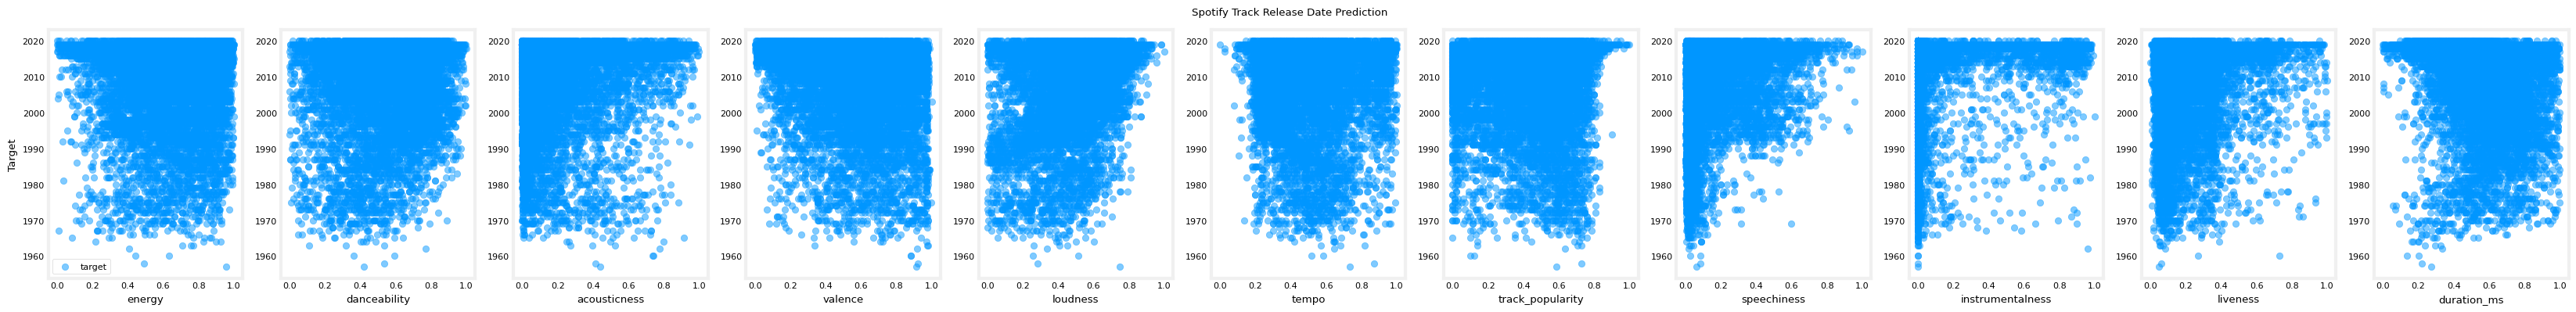

In [ ]:
if len(x_name) == 1:
    plt.scatter(x, y, marker="x", c="r")
    plt.title("Spotify Track Release Date Prediction")
    plt.ylabel(f"Training {y_name}")
    plt.xlabel(f"Training {x_name[0]}")
else:
    fig, ax = plt.subplots(1, len(x_name), figsize=(len(x_name) * 3, 4))
    for i in range(len(ax)):
        ax[i].scatter(x[:, i], y, label="target", alpha=0.5)
        ax[i].set_xlabel(x_name[i])
    ax[0].set_ylabel("Target")
    ax[0].legend()
    fig.suptitle("Spotify Track Release Date Prediction")
    plt.tight_layout()
plt.show()

#### Step 4

Then save an instance of PolynomialFeatures, adjust the 'degree' parameter to suit your model and create the feature using the data in 'x'. (Note a degree of 1 is linear regression, each extra degree adds a coefficient). I found that a degree of 2 worked the best while not overfitting.

Then use the [Scikit-learn](https://scikit-learn.org/stable/) library to instantiate a Machine Learning model class and store it in the `my_model` variable as an object.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(x)

# Create the model
my_model = LinearRegression()
# Fit the model to the data
my_model.fit(poly_features, y)

#### Step 5

Plot the features, targets and model.

R: 0.6221
R^2: 0.3870


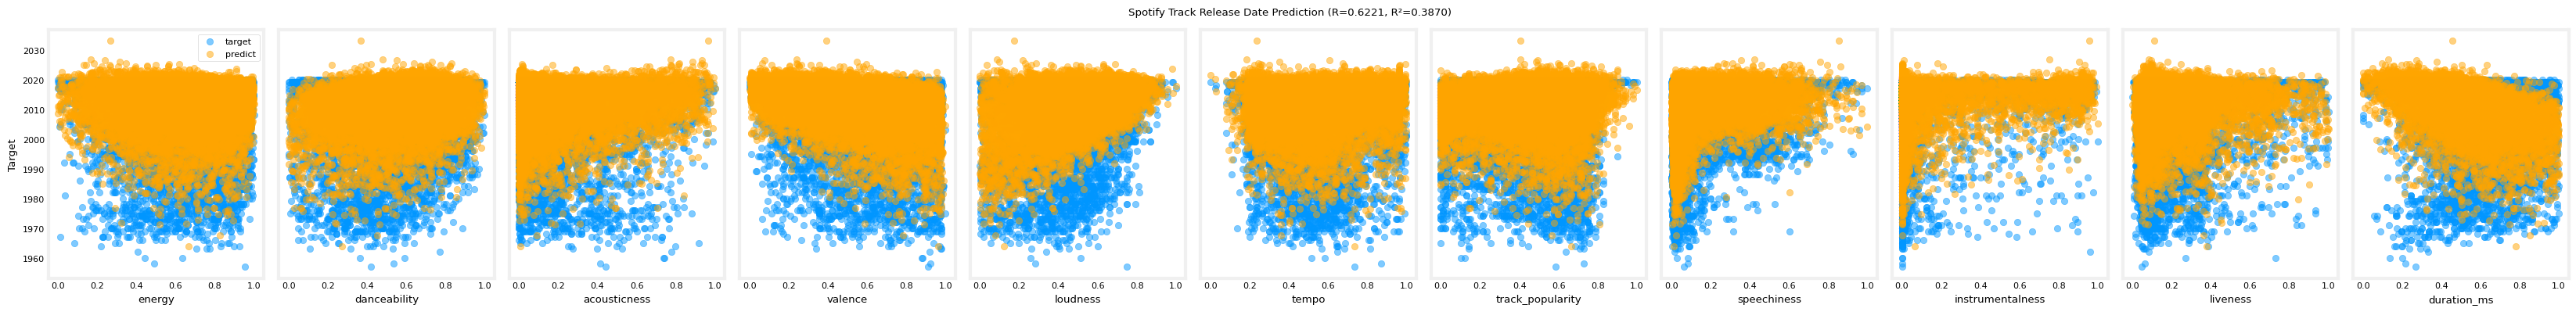

In [15]:
y_pred = my_model.predict(poly_features)

r = np.corrcoef(y, y_pred)[0, 1]
r2 = my_model.score(poly_features, y)

print(f"R: {r:.4f}")
print(f"R^2: {r2:.4f}")

if len(x_name) == 1:
    plt.scatter(x, y_pred, alpha=0.5)
    plt.scatter(x, y, marker="x", c="r", alpha=0.5)
    plt.title(f"Spotify Track Release Date Prediction (R={r:.4f}, R²={r2:.4f})")
    plt.ylabel(f"Training {y_name}")
    plt.xlabel(f"Training {x_name[0]}")
else:
    fig, ax = plt.subplots(1, len(x_name), figsize=(len(x_name) * 3, 4), sharey=True)
    for i in range(len(ax)):
        ax[i].scatter(x[:, i], y, label="target", alpha=0.5)
        ax[i].scatter(x[:, i], y_pred, color="orange", label="predict", alpha=0.5)
        ax[i].set_xlabel(x_name[i])
    ax[0].set_ylabel("Target")
    ax[0].legend()
    fig.suptitle(f"Spotify Track Release Date Prediction (R={r:.4f}, R²={r2:.4f})")
    plt.tight_layout()
plt.show()

In [16]:
poly_filename = "my_saved_poly_v3.pkl"
with open("../2.4.Model_Testing_and_Validation/" + poly_filename, "wb") as f:
    pickle.dump(poly, f)

model_filename = "my_saved_model_v3.sav"
with open("../2.4.Model_Testing_and_Validation/" + model_filename, "wb") as f:
    pickle.dump(my_model, f)

print(f"Poly saved:  {poly_filename}")
print(f"Model saved: {model_filename}")

Poly saved:  my_saved_poly_v3.pkl
Model saved: my_saved_model_v3.sav


#### Step 6. Explore polynomial degrees

Here I create a graph to see how different polynomial degrees affect my determinent of correlation (R squared).

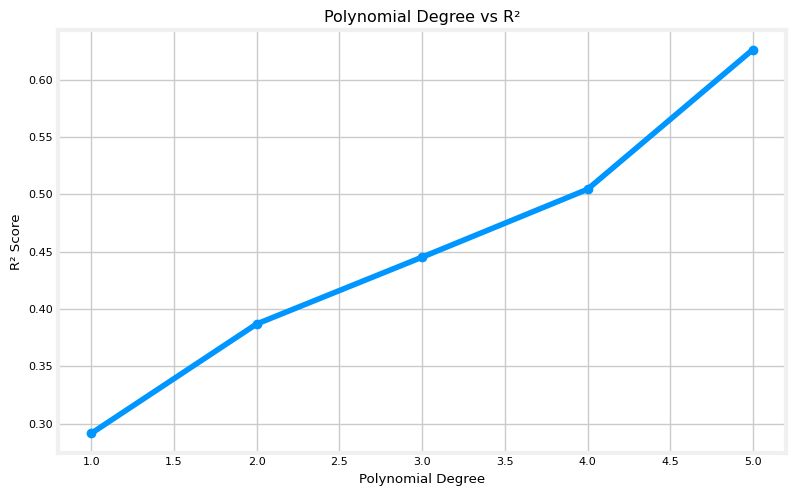


Degree | R²
--------------------
  1    | 0.2914
  2    | 0.3870
  3    | 0.4453
  4    | 0.5045
  5    | 0.6266


In [17]:
# Cell - Step 6: Explore polynomial degrees
degrees = range(1, 6)
r2_scores = []

for deg in degrees:
    pf = PolynomialFeatures(degree=deg, include_bias=False)
    x_poly = pf.fit_transform(x)
    model = LinearRegression()
    model.fit(x_poly, y)
    r2_scores.append(model.score(x_poly, y))

plt.figure(figsize=(8, 5))
plt.plot(degrees, r2_scores, marker="o")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs R²")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nDegree | R²")
print("-" * 20)
for d, r2 in zip(degrees, r2_scores):
    print(f"  {d}    | {r2:.4f}")